# Importing Project Excel File 

In [1]:
import pandas as pd

In [14]:
online_df = pd.read_excel('online_retail_II.xlsx')

In [15]:
online_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [16]:
online_df['InvoiceDate'].max()

Timestamp('2010-12-09 20:01:00')

In [17]:
online_df = online_df.dropna(subset=['Customer ID'])

In [18]:
online_df.shape

(417534, 8)

# Selecting 100K Random Rows to Enhance query speed

In [19]:
sample_df = online_df.sample(n=100000, random_state=42)

In [20]:
sample_df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [21]:
sample_df.shape

(100000, 8)

In [22]:
sample_df.columns = [
    "invoice",
    "stock_code",
    "description",
    "quantity",
    "invoice_date",
    "price",
    "customer_id",
    "country"
]

In [23]:
sample_df.head()

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
47316,493812,84993B,75 BLACK PETIT FOUR CASES,24,2010-01-07 11:52:00,0.42,13081.0,United Kingdom
25260,491497,21175,GIN + TONIC DIET METAL SIGN,48,2009-12-11 12:17:00,1.85,17409.0,United Kingdom
65994,495289,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2010-01-22 12:37:00,0.65,17519.0,United Kingdom
369178,525065,21156,RETROSPOT CHILDRENS APRON,1,2010-10-03 14:28:00,1.95,16799.0,United Kingdom
462557,533074,21814,HEART T-LIGHT HOLDER,12,2010-11-16 07:52:00,1.25,14298.0,United Kingdom


In [24]:
sample_df.dtypes

invoice                 object
stock_code              object
description             object
quantity                 int64
invoice_date    datetime64[ns]
price                  float64
customer_id            float64
country                 object
dtype: object

# Data Preprocessing

In [25]:
sample_df["customer_id"] = sample_df["customer_id"].astype(int)

In [18]:
sample_df.head()

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
47316,493812,84993B,75 BLACK PETIT FOUR CASES,24,2010-01-07 11:52:00,0.42,13081,United Kingdom
25260,491497,21175,GIN + TONIC DIET METAL SIGN,48,2009-12-11 12:17:00,1.85,17409,United Kingdom
65994,495289,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2010-01-22 12:37:00,0.65,17519,United Kingdom
369178,525065,21156,RETROSPOT CHILDRENS APRON,1,2010-10-03 14:28:00,1.95,16799,United Kingdom
462557,533074,21814,HEART T-LIGHT HOLDER,12,2010-11-16 07:52:00,1.25,14298,United Kingdom


# Exporting Data to csv file to use in MySQL

In [19]:
sample_df.to_csv("SQL_project.csv", index=False)

# Data Visualizations for Exploratory Data Analysis conducted in MySQL

In [20]:
line_df = pd.read_csv('SQL_line_chart.csv')

In [21]:
line_df

,order_month,total_orders,total_revenue
0,12-2009,1295,158962.760
1,01-2010,849,133624.081
2,02-2010,947,124563.662
3,03-2010,1337,168400.921
4,04-2010,1143,144861.531
5,05-2010,1155,143427.380
6,06-2010,1257,163245.460
7,07-2010,1161,143328.780
8,08-2010,1113,153545.010
9,09-2010,1417,199259.001


In [22]:
line_df.dtypes

order_month       object
total_orders       int64
total_revenue    float64
dtype: object

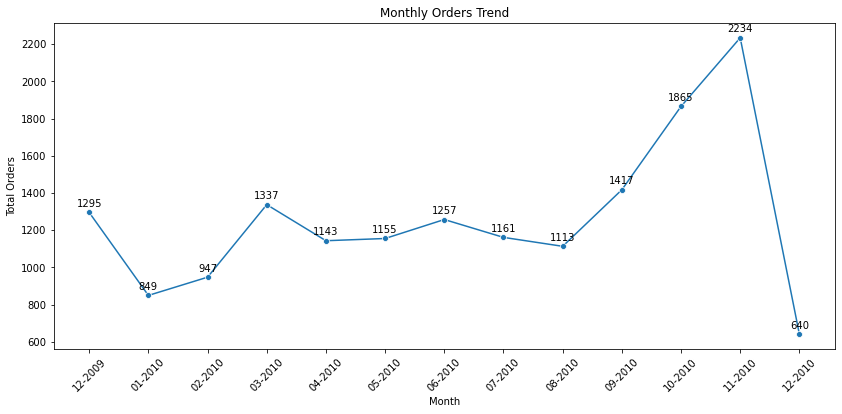

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize =(14,6))
sns.lineplot(data = line_df, x='order_month', y = 'total_orders',marker ='o')
for i, value in enumerate(line_df['total_orders']):
    plt.text(i, value+20, str(value), ha='center', va='bottom')
plt.xticks(rotation=45)
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.show()

In [59]:
line_df = pd.read_csv('SQL_line_chart.csv')

In [61]:
line_df['total_revenue'] = (line_df['total_revenue'] /1000)
line_df['total_revenue']= line_df['total_revenue'].round(2)


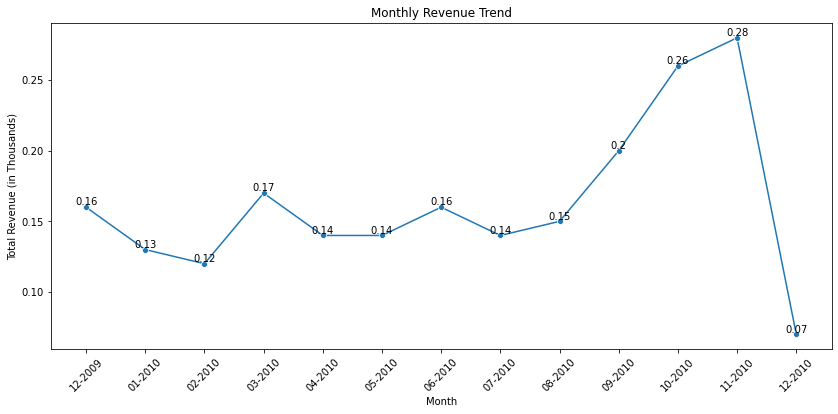

In [64]:
plt.figure(figsize =(14,6))
sns.lineplot(data = line_df, x='order_month', y = 'total_revenue',marker ='o')
for i, value in enumerate(line_df['total_revenue']):
    plt.text(i, value, str(value), ha='center', va='bottom')
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue (in Thousands)")
plt.show()

In [67]:
CPF_df = pd.read_csv('Customer_Purchase_frequency.csv')

In [81]:
CPF_df.rename(columns ={'Customers_with_1_order':'1 order', 'Customers_with_2_to_5_orders':'2-5 orders',
                         'Customers_with_6_to_10_orders':'6-10 orders', 'Customers_with_more_than_10_orders':'>10 orders'},inplace =True)

In [82]:
CPF_df

,1 order,2-5 orders,6-10 orders,>10 orders
0,1450,1868,533,257


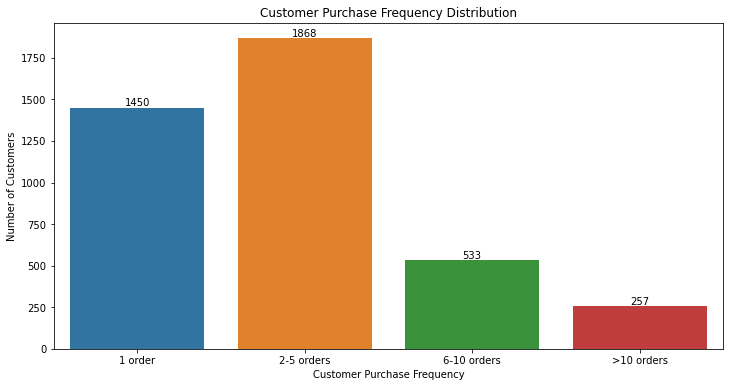

In [87]:
CPF_df_long = CPF_df.melt(var_name='Purchase_Category', value_name='Customers')

plt.figure(figsize =(12,6))
ax = sns.barplot(data = CPF_df_long, x ='Purchase_Category', y= 'Customers')

for container in ax.containers:
    ax.bar_label(container)

plt.xlabel("Customer Purchase Frequency")
plt.ylabel("Number of Customers")
plt.title("Customer Purchase Frequency Distribution")
#plt.xticks(rotation=45)
plt.show()

In [88]:
ov_df = pd.read_csv('order_revenue.csv')

In [89]:
ov_df.shape

(16413, 2)

In [90]:
ov_df.head()

,order_id,order_value
0,489434,170.50
1,489435,30.60
2,489436,155.05
3,489437,17.70
4,489438,27.44


In [92]:
ov_df['order_value'].max()

13032.26

In [96]:
ov_df[ov_df['order_value'] > 1000].shape

(162, 2)

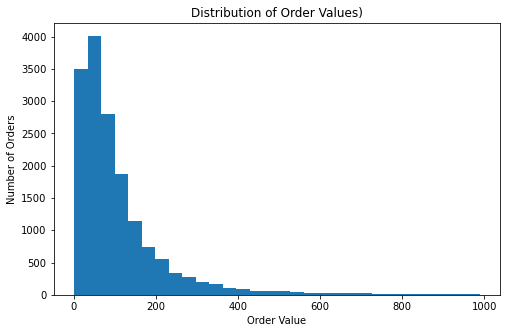

In [99]:

filtered_orders = ov_df[ov_df['order_value'] <= 1000]

plt.figure(figsize=(8,5))

plt.hist(filtered_orders['order_value'], bins=30)

plt.xlabel('Order Value')
plt.ylabel('Number of Orders')
plt.title('Distribution of Order Values)')

plt.show()

In [2]:
country_df = pd.read_csv('Country_Revenue.csv')

In [3]:
country_df['total_revenue'] = country_df['total_revenue']/1000

In [4]:
country_df['total_revenue'] = country_df['total_revenue'].round(2)

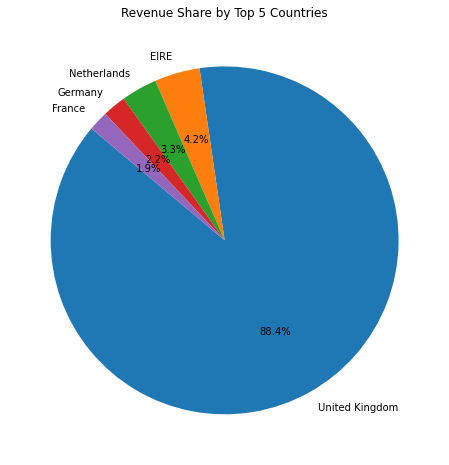

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))

plt.pie(
    country_df[:5]['total_revenue'],
    labels=country_df[:5]['country'],
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Revenue Share by Top 5 Countries")
plt.show()

In [2]:
cus_df = pd.read_csv('Customer_Lifetime_Value.csv')

In [3]:
cus_df

,customer_id,total_orders,total_customer_revenue,avg_order_value
0,18102,65,92319.16,1420.294769
1,14646,59,62297.15,1055.883898
2,14156,78,44408.93,569.345256
3,14911,178,39426.38,221.496517
4,13694,66,34645.91,524.938030
5,17511,27,23613.14,874.560741
6,15061,56,21340.23,381.075536
7,16754,19,20516.28,1079.804210
8,16684,17,18194.83,1070.284118
9,17450,6,16179.28,2696.546667


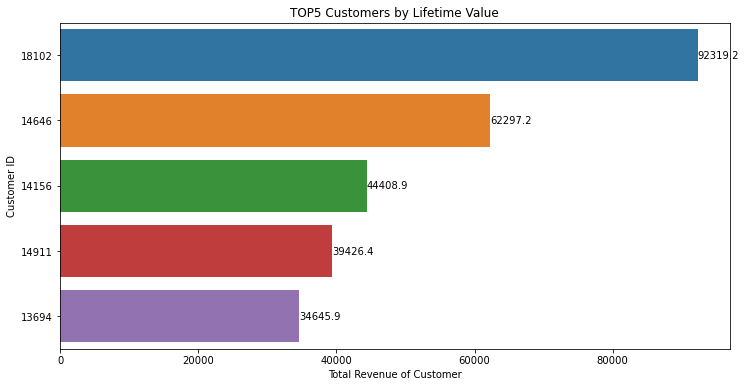

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize =(12,6))
ax = sns.barplot(data = cus_df[:5] , y ='customer_id',x = 'total_customer_revenue',orient ='h', order = cus_df[:5]['customer_id'])
for container in ax.containers:
    ax.bar_label(container)
plt.ylabel('Customer ID')
plt.xlabel('Total Revenue of Customer')
plt.title('TOP5 Customers by Lifetime Value')
plt.show()

In [25]:
product_h_df = pd.read_csv('Highest_Revenue_products.csv')

In [26]:
product_h_df

,product_id,product_name,quantity_sold,total_revenue_generated
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,13940,37217.02
1,22423,REGENCY CAKESTAND 3 TIER,3212,36802.20
2,M,Manual,586,30214.95
3,85099B,JUMBO BAG RED RETROSPOT,12286,21524.70
4,84879,ASSORTED COLOUR BIRD ORNAMENT,9415,15068.47
5,21843,RED RETROSPOT CAKE STAND,1292,13017.44
6,48138,DOOR MAT UNION FLAG,1905,12172.29
7,21623,VINTAGE UNION JACK MEMOBOARD,1634,11271.06
8,POST,POSTAGE,453,10933.00
9,22086,PAPER CHAIN KIT 50'S CHRISTMAS,3931,10456.05


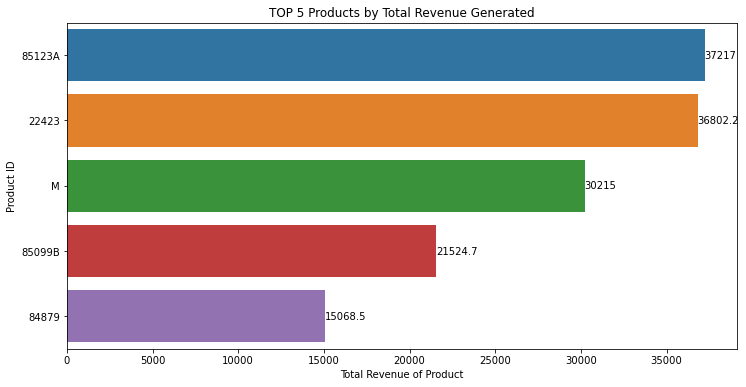

In [27]:
plt.figure(figsize =(12,6))
ax = sns.barplot(data = product_h_df[:5] , y ='product_id',x = 'total_revenue_generated',orient ='h', order = product_h_df[:5]['product_id'])
for container in ax.containers:
    ax.bar_label(container)
plt.ylabel('Product ID')
plt.xlabel('Total Revenue of Product')
plt.title('TOP 5 Products by Total Revenue Generated')
plt.show()

In [28]:
product_q_df = pd.read_csv('Most_popular_products.csv')

In [29]:
product_q_df

,product_id,product_name,quantity_sold,total_revenue_generated
0,21984,PACK OF 12 PINK PAISLEY TISSUES,14730,3709.46
1,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,14675,2987.27
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,13940,37217.02
3,85099B,JUMBO BAG RED RETROSPOT,12286,21524.70
4,21212,PACK OF 72 RETRO SPOT CAKE CASES,12108,5880.60
5,21981,PACK OF 12 WOODLAND TISSUES,11757,2997.75
6,17003,BROCADE RING PURSE,11393,1991.13
7,84879,ASSORTED COLOUR BIRD ORNAMENT,9415,15068.47
8,20993,JAZZ HEARTS MEMO PAD,9366,977.10
9,22197,"POPCORN HOLDER , SMALL",8435,6376.23


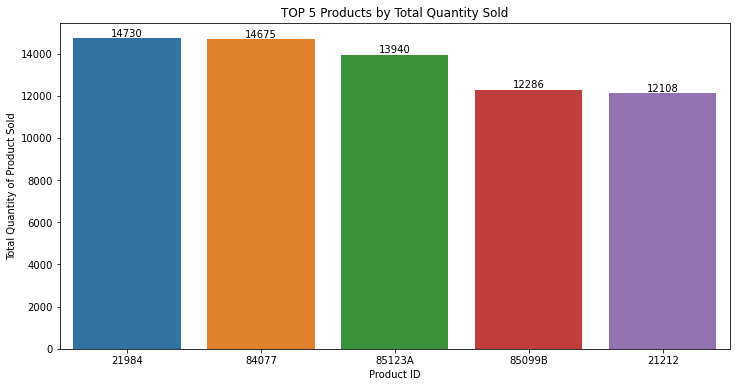

In [31]:
plt.figure(figsize =(12,6))
ax = sns.barplot(data = product_q_df[:5] , x ='product_id',y = 'quantity_sold', order = product_q_df[:5]['product_id'])
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel('Product ID')
plt.ylabel('Total Quantity of Product Sold')
plt.title('TOP 5 Products by Total Quantity Sold')
plt.show()

# Data Visualization for Churn and Retention Analysis performed in MySQL

In [33]:
churn_df = pd.read_csv('Churn_vs_frequency.csv')

In [36]:
churn_df.sort_values(by ='churn_rate',ascending =False,inplace=True)
churn_df

,customer_order_segment,total_customers,churn_customers,churn_rate,retention_rate
1,1 order,1450,791,54.55172,45.44828
0,2 to 5 orders,1868,527,28.21199,71.78801
2,6 to 10 orders,533,40,7.50469,92.49531
3,>10 orders,257,10,3.89105,96.10895


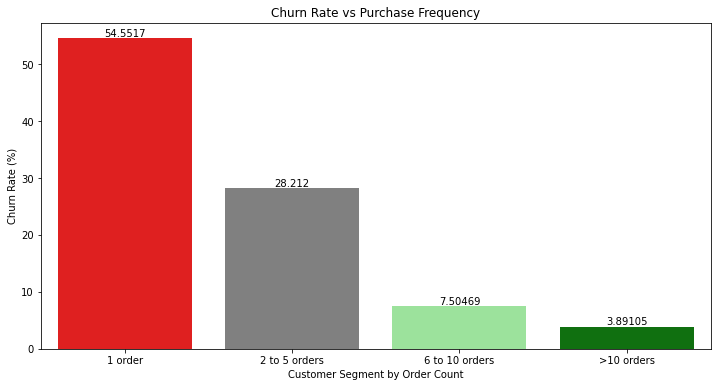

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

palette = {
    '1 order': 'red',
    '2 to 5 orders': 'grey',
    '6 to 10 orders': 'lightgreen',
    '>10 orders': 'green'
}
plt.figure(figsize =(12,6))
ax = sns.barplot(data =churn_df,x='customer_order_segment',y='churn_rate',order = churn_df['customer_order_segment'],palette =palette)
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel('Customer Segment by Order Count')
plt.ylabel('Churn Rate (%)')
plt.title ('Churn Rate vs Purchase Frequency')
plt.show()

In [47]:
value_df = pd.read_csv('churn_vs_Value.csv')
value_df

,customer_value_segment,total_customers,churn_customers,churn_rate,retention_rate
0,Low Value,1370,722,52.70073,47.29927
1,Medium Value,1369,439,32.06720,67.93280
2,High Value,1369,207,15.12053,84.87947


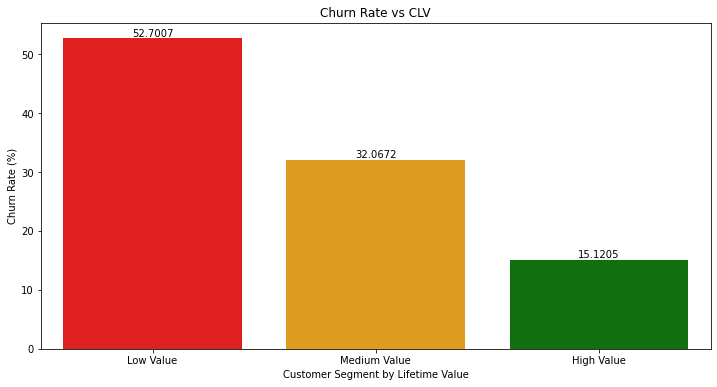

In [49]:
palette = {
    'Low Value': 'red',
    'Medium Value': 'orange',
    'High Value': 'green'
}
plt.figure(figsize =(12,6))
ax = sns.barplot(data =value_df,x='customer_value_segment',y='churn_rate',palette =palette)
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel('Customer Segment by Lifetime Value')
plt.ylabel('Churn Rate (%)')
plt.title ('Churn Rate vs CLV')
plt.show()

In [50]:
rev_df = pd.read_csv('revenue_churn.csv')

In [51]:
rev_df.shape

(1368, 2)

In [52]:
rev_df.head()

,customer_id,customer_revenue
0,13085,544.90
1,15413,305.76
2,16321,50.40
3,17592,25.35
4,12533,326.58


In [54]:
filt_rev_df = rev_df[rev_df['customer_revenue'] < 1000]

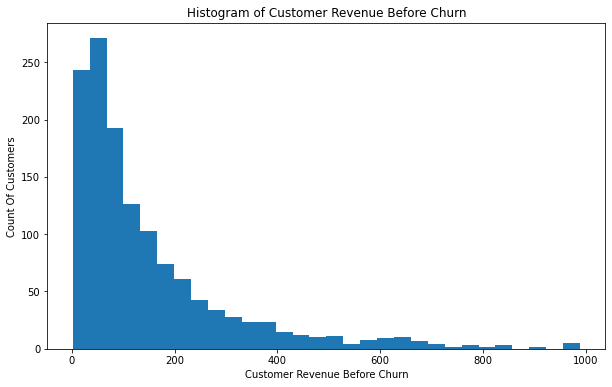

In [60]:
plt.figure(figsize =(10,6))
plt.hist(filt_rev_df['customer_revenue'],bins=30)
plt.xlabel('Customer Revenue Before Churn')
plt.ylabel('Count Of Customers')
plt.title('Histogram of Customer Revenue Before Churn')
plt.show()

In [9]:
rfm_df = pd.read_csv('RFM_segment.csv')

In [65]:
rfm_df.sort_values(by ='number_of_customers',ascending = False,inplace = True)
rfm_df

,rfm_segment,number_of_customers,total_revenue,overall_revenue,revenue_percentage
1,Others,1379,234476.910,2138331.596,10.965414
3,Loyal Customers,1323,1555827.703,2138331.596,72.758954
0,New Customers,889,94126.952,2138331.596,4.401888
2,At Risk,273,72994.430,2138331.596,3.413616
4,Champions,244,180905.601,2138331.596,8.460129


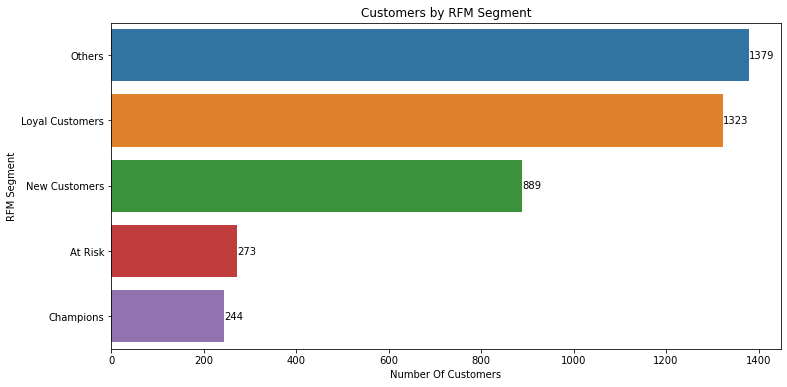

In [66]:
plt.figure(figsize =(12,6))
ax = sns.barplot(data = rfm_df , y ='rfm_segment',x = 'number_of_customers',orient ='h',order=rfm_df['rfm_segment'])
for container in ax.containers:
    ax.bar_label(container)
plt.ylabel('RFM Segment')
plt.xlabel('Number Of Customers')
plt.title('Customers by RFM Segment')
plt.show()

In [10]:
rfm_df.sort_values(by ='revenue_percentage',ascending = False,inplace = True)

In [11]:
rfm_df

,rfm_segment,number_of_customers,total_revenue,overall_revenue,revenue_percentage
3,Loyal Customers,1323,1555827.703,2138331.596,72.758954
1,Others,1379,234476.910,2138331.596,10.965414
4,Champions,244,180905.601,2138331.596,8.460129
0,New Customers,889,94126.952,2138331.596,4.401888
2,At Risk,273,72994.430,2138331.596,3.413616


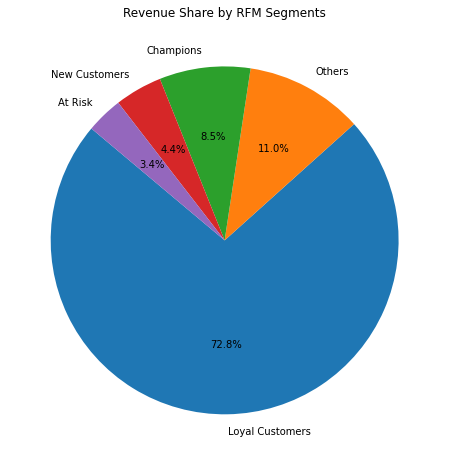

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))

plt.pie(
    rfm_df['total_revenue'],
    labels=rfm_df['rfm_segment'],
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Revenue Share by RFM Segments")
plt.show()

In [2]:
cohort_df = pd.read_csv('Cohort_Analysis.csv')

In [3]:
cohort_df

,cohort_month,month_number,active_customers,retention_rate
0,2009-12,0,879,100.00000
1,2009-12,1,328,37.31513
2,2009-12,2,294,33.44710
3,2009-12,3,343,39.02162
4,2009-12,4,334,37.99772
...,...,...,...,...
86,2010-10,1,73,19.41489
87,2010-10,2,4,1.06383
88,2010-11,0,324,100.00000
89,2010-11,1,4,1.23457


In [4]:
cohort_pivot = cohort_df.pivot(
    index='cohort_month',
    columns='month_number',
    values='retention_rate'
)
cohort_pivot.columns = ['M' + str(col) for col in cohort_pivot.columns]
cohort_pivot

,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12
cohort_month,,,,,,,,,,,,,
2009-12,100.0,37.31513,33.44710,39.02162,37.99772,34.92605,35.03982,33.21957,31.51308,35.83618,41.18316,49.14676,10.5802
2010-01,100.0,27.80899,26.68539,30.89888,32.58427,24.15730,23.87640,26.40449,32.30337,29.21348,21.62921,0.56180,NaN
2010-02,100.0,23.05476,25.07205,25.36023,22.76657,19.88473,21.32565,27.95389,26.22478,19.02017,0.86455,NaN,NaN
2010-03,100.0,23.52941,23.52941,22.11765,21.88235,18.58824,28.47059,30.82353,19.52941,0.94118,NaN,NaN,NaN
2010-04,100.0,18.72792,18.72792,18.02120,18.37456,27.20848,27.20848,16.25442,0.70671,NaN,NaN,NaN,NaN
2010-05,100.0,14.52282,20.33195,15.35270,19.50207,21.99170,17.84232,1.65975,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,16.66667,15.11628,24.03101,22.86822,22.48062,0.77519,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,18.13187,28.02198,24.72527,21.42857,2.19780,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,22.92994,32.48408,19.10828,2.54777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


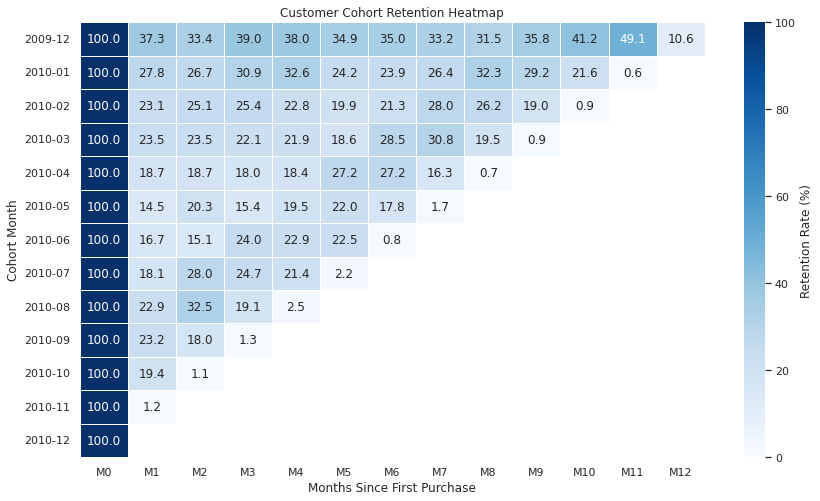

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

cohort_pivot = cohort_pivot.round(1)

sns.set_theme(style="white")

plt.figure(figsize=(14,8))

mask = cohort_pivot.isna()

sns.heatmap(
    cohort_pivot,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5,
    mask=mask,
    vmin=0,
    vmax=100,
    cbar_kws={'label': 'Retention Rate (%)'}
)

plt.title("Customer Cohort Retention Heatmap")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

In [6]:
churn_products_df = pd.read_csv('churn_by_products.csv')

,product_id,product_name,churned_customers,active_customers,churn_customer_percentage
0,22290,STANDING METAL RABBIT WITH EGG,10,10,50.00
1,21542,WOODLAND WATER TRANSFER TATTOOS,11,14,44.00
2,21718,RED METAL BEACH SPADE,15,22,40.54
3,21224,SET/4 SKULL BADGES,8,12,40.00
4,21410,COUNTRY COTTAGE DOORSTOP GREEN,10,16,38.46
...,...,...,...,...,...
1230,22983,CARD BILLBOARD FONT,0,25,0.00
1231,72799E,IVORY PILLAR CANDLE SILVER FLOCK,0,22,0.00
1232,84352,SILVER CHRISTMAS TREE BAUBLE STAND,0,23,0.00
1233,85226A,WHITE/BLUE PULL BACK RACING CAR,0,22,0.00


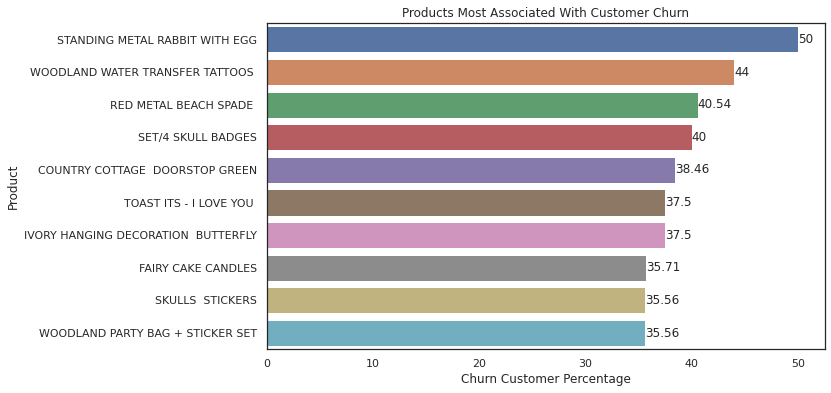

In [10]:
plt.figure(figsize=(10,6))

ax= sns.barplot(
    data=churn_products_df[:10],
    y="product_name",
    x="churn_customer_percentage",
    order = churn_products_df[:10]['product_name']
)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Products Most Associated With Customer Churn")
plt.xlabel("Churn Customer Percentage")
plt.ylabel("Product")

plt.show()